In [188]:
import pandas as pd
import numpy as np
df = pd.read_csv("merged_data_quant_trading_model.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")
print(df)

#sorts all the values in ascending order by date (oldest to most recent)
#makes sure data column is in datetime format 

           date  emb_price  credit_spread  oil_price    vix
0    2016-04-08     110.05           4.30      80.24  15.36
1    2016-04-11     110.54           4.26      82.24  16.26
2    2016-04-12     110.69           4.15      85.12  14.85
3    2016-04-13     111.15           4.05      84.08  13.84
4    2016-04-14     111.29           3.99      83.84  13.72
...         ...        ...            ...        ...    ...
2508 2026-03-31      93.93           2.08     127.25  25.25
2509 2026-04-01      93.86           1.97     124.09  24.54
2510 2026-04-02      93.97           1.98     137.92  23.87
2511 2026-04-06      93.94           1.86     138.94  24.17
2512 2026-04-07      93.99           1.92     138.08  25.78

[2513 rows x 5 columns]


In [189]:
#feature engineering - creating transformed variables
"""we want to convert from prices to returns for all the variables b/c returns are more commonly used in finance, 
more directly linked to trading signal, 
& easier to evaluate performance"""
"""more directly linked to signal b/c trades earn returns - Strategy return @ time t = Signal @ time t x return @ time t+1"""
"""So predicting returns directly maps to profits"""
"""By look-ahead bias, that means using future information to predict the past"""
"""For example, using vix returns at time t+1 to predict the emb return at time t+1 as well"""
"""This is wrong b/c we need the predictor variables to be 1 time period before the dependent variable!"""
"""To ensure we have the 1 time period difference, that is why we did the .shift(-1) method!
- ensures we aren't using future info to predict the past"""

#1. EMB Returns
df["em_return"] = np.log(df["emb_price"] / df["emb_price"].shift(1))
#2. Oil returns 
df["oil_return"] = np.log(df["oil_price"] / df["oil_price"].shift(1))
#3. VIX change
df["delta_vix"] = df["vix"].diff()
#4. Credit spread change
df["delta_spread"] = df["credit_spread"].diff()


"""We use returns for oil because oil is a tradeable asset price - so looking at return tells us % changes, 
and that is standard in finance"""
"""Vix is a volatility index - its NOT a price! So, it doesn't make sense to use vix returns - 
but it makes more sense to look at changes in vix (deltas)"""
"""Changes in vix demonstrate shocks to volatility and changes in the level of fear"""
"""For credit spreads we don't use returns because credit spreads are already expressed in percentage units, 
so we just take the difference between spread at time t and time t-1"""


"For credit spreads we don't use returns because credit spreads are already expressed in percentage units, \nso we just take the difference between spread at time t and time t-1"

In [190]:
"""Next part - we want to use today's variables 
to predict tomorrow's emb returns"""
# Use predictors observed at time t to predict EMB return at time t+1.
# Oil is expressed as a log return; VIX and credit spreads are expressed as daily changes.
"""so the idea is that we observe the vix, credit spread, and oil returns at time t 
& we use that information to predict emb returns at time t+1"""
"""We do this with the line of code below with target"""

df["target"] = df["em_return"].shift(-1)


#clean data by removing null values w/ dropna
df = df.dropna()

In [191]:
df[["em_return", "target"]].head()
#This proves that the target was shifted correctly
#We want today's row to predict tomorrow's return 
#This means target at time t (today) = em_return at time t+1 (tomorrow)
#So if 1 is today (time t), then target is 0.001356
#Then we want to make sure that target at time 1 = em_return at time 2
#This checks out - target at time 1 = 0.001356 = em_return at time 2
#Similarly, target at time 2 = 0.004147 = em_return at time 3
#Target at time 3 = 0.001259 = em_return at time 4
#Target at time 4 = 0.000539 = em_return at time 5

# This aligns each row's predictors at time t with the EMB return at time t+1.
# Avoiding look-ahead bias also requires using only information available at time t
# and maintaining the chronological train/test split.

,em_return,target
1,0.004443,0.001356
2,0.001356,0.004147
3,0.004147,0.001259
4,0.001259,0.000539
5,0.000539,0.000539


In [192]:
#now, we can construct a correlation matrix to see which predictors move most strongly with the emb returns and in what direction
#i.e. do em_returns and oil_returns move positively? Meaning that as oil_returns increase, so do em_returns etc 
#Correlation of around 0.24 between oil_returns and em_returns, which is mild positive
#Correlation of around -0.47 between delta_vix and emb_returns, which is strong negative - so when VIX rises, em_returns fall
#Correlation of around -0.35 between delta_spread and emb_returns, which is moderate negative - so when credit_spreads widen, emb_returns fall
df[["em_return", "oil_return", "delta_vix", "delta_spread"]].corr()

,em_return,oil_return,delta_vix,delta_spread
em_return,1.000000,0.236911,-0.465797,-0.353212
oil_return,0.236911,1.000000,-0.249915,-0.295493
delta_vix,-0.465797,-0.249915,1.000000,0.456633
delta_spread,-0.353212,-0.295493,0.456633,1.000000


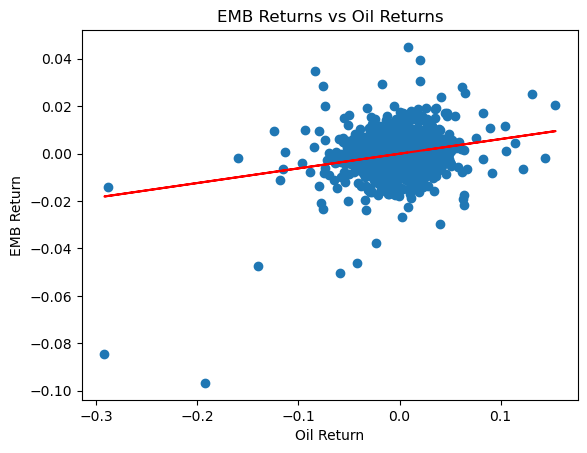

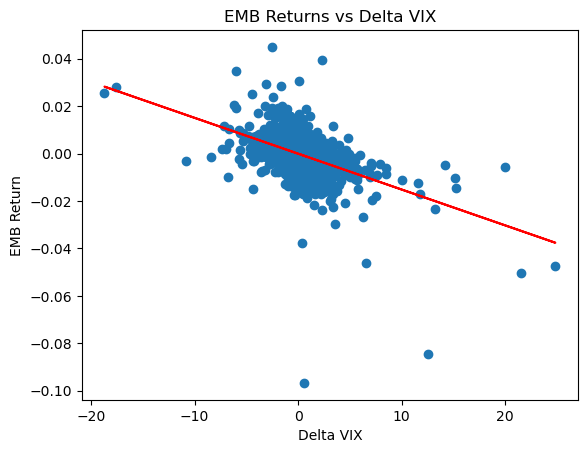

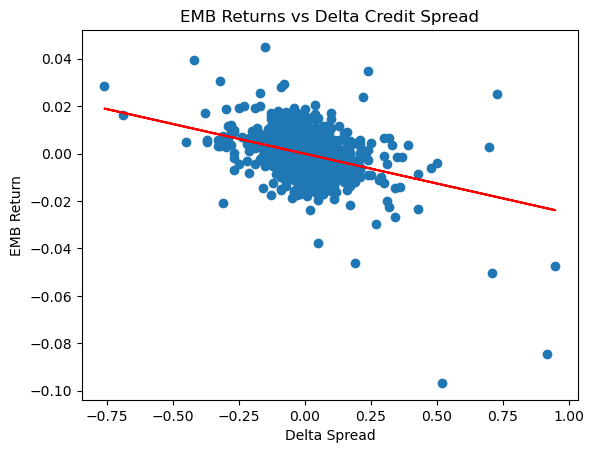

"HOWEVER, correlation does NOT mean causation! \nCurrently, looking strictly at correlation would imply that VIX is strongest, then credit spreads, then oil.\nBut, this doesn't account for how well these variables could work together simultaneously to explain emb returns - so more analysis is needed!\nSpecifically, we will test a few independent bivariate linear relationships to see how strong each predictor is individually,\nand we will also test a multivariate regression with all predictors to see how effective the model would be when all 3 predictors\nwork together simultaneously to predict emb returns"

In [193]:
#to better visualize the relationships between these variables, we will use scatterplots to display the data
import matplotlib.pyplot as plt

# EM vs Oil

#line of best fit
m,b = np.polyfit(df["oil_return"],df["em_return"],1)

plt.figure()
plt.scatter(df["oil_return"], df["em_return"])
plt.plot(df["oil_return"],m*df["oil_return"] + b,color="red")
plt.xlabel("Oil Return")
plt.ylabel("EMB Return")
plt.title("EMB Returns vs Oil Returns")
plt.show()

"""We see that there appears to be a positive relationship on the graph - as oil returns increase, emb returns appear to increase
but there appears to be a lot of variability in the data points (quite spread out) - so relationship is noisy
that's why there is a weak positive relationship, having only a correlation of +0.24"""

# EM vs VIX
#line of best fit
m,b = np.polyfit(df["delta_vix"],df["em_return"],1)

plt.figure()
plt.scatter(df["delta_vix"], df["em_return"])
plt.plot(df["delta_vix"],m*df["delta_vix"] + b,color="red")
plt.xlabel("Delta VIX")
plt.ylabel("EMB Return")
plt.title("EMB Returns vs Delta VIX")
plt.show()

"""We see that there appears to be a clear negative relationship on the graph - as delta_vix increase, emb returns appear to decrease
there appears to be less variability in the data points (more clustered together) - so relationship is less noisy
that explains why there is a strong correlation of -0.47"""

# EM vs Credit Spread

#line of best fit
m,b = np.polyfit(df["delta_spread"],df["em_return"],1)

plt.figure()
plt.scatter(df["delta_spread"], df["em_return"])
plt.plot(df["delta_spread"],m*df["delta_spread"] + b,color="red")
plt.xlabel("Delta Spread")
plt.ylabel("EMB Return")
plt.title("EMB Returns vs Delta Credit Spread")
plt.show()

"""We see that there appears to be a negative relationship on the graph - as delta_spreads increases, emb returns appears to decrease
there appears to be decent variability in the data points (data points quite clutered together, but still noticeable amount 
of spreading out of the data points) 
so relationship is a little more noisy, and that explains why there is moderately strong correlation of -0.35"""


"""HOWEVER, correlation does NOT mean causation! 
Currently, looking strictly at correlation would imply that VIX is strongest, then credit spreads, then oil.
But, this doesn't account for how well these variables could work together simultaneously to explain emb returns - so more analysis is needed!
Specifically, we will test a few independent bivariate linear relationships to see how strong each predictor is individually,
and we will also test a multivariate regression with all predictors to see how effective the model would be when all 3 predictors
work together simultaneously to predict emb returns"""

In [194]:
df[["em_return", "oil_return", "delta_vix", "delta_spread"]].kurtosis()
# pandas .kurtosis() reports excess kurtosis, where a normal distribution = 0.
# The very large positive values indicate heavy tails and extreme observations.
#For all of these predictor variables and the em_return, the kurtosis is much higher than that (ranging from 19.92 to 39.16)
# Large positive excess kurtosis indicates heavy tails and unusually extreme observations.
#This reflects the reality of finance - where data over the past 10 yrs reflects various spikes, shocks, and crises 
#It means the market behavior is strongly influenced by rare, extreme tail events such as spikes/crises 
#rather than average conditions on day-day basis

em_return       39.178317
oil_return      20.553920
delta_vix       32.486428
delta_spread    19.905511
dtype: float64

In [195]:
#Issue is that some violations for OLS are violated
"""OLS assumes linear relationship between variables, independent errors (error at time t is independent of error at time t-1 
this means today's prediction error is not related to yesterday's error),
homoskedasticity, residuals are normally distributed, and no multicollinearity"""

#however, independent errors is violated b/c of autocorrelation (if one day there is a stock mkt crash, the next day is still turbulent) 
#so, if model underpredicts crash today, it will also underpredict crash tmrw if treating errors as independent from today and tmrw
"""so there is actually a correlation/dependence on errors over time in reality in financial mkts,
which is why independent errors assumption is violated
- in crises all correlations go to 1 idea is the reality - that definetely violates the independent errors assumption"""

#homoskedacity - means the error term has same variance over time (across all t values)
#But, in reality, financial mkts display volatility clustering - which means there is low variance for errors in quiet times
#, and in times of crises there are huge surges in the error (high variances)
#so homoskedacity is violated b/c error size changes over time
#independent errors is violated due to autocorrelation, which means errors move together over time

# Financial return data can challenge standard OLS inference because residuals
# may be heteroskedastic and heavy-tailed, and relationships may change over time.
# Residual diagnostics show substantial non-normality/heavy tails.
# HC3 provides heteroskedasticity-robust standard errors, but does not correct
# nonlinearity, regime changes, or serial dependence if present.

"""
normally distributed residuals (differences between observed and predicted values) is violated b/c very high kurtosis,
so outliers are extreme and concentrated tail events
"""

#no multicollinearity violated because delta_spread and delta_vix have strong correlation of 0.46

#Summary
# Financial return data may challenge standard OLS assumptions because of
# heteroskedasticity, heavy-tailed residuals, nonlinear relationships, and
# changing market conditions. HC3 provides heteroskedasticity-robust
# standard errors, but does not correct nonlinearity or changing regimes.

'\nnormally distributed residuals (differences between observed and predicted values) is violated b/c very high kurtosis,\nso outliers are extreme and concentrated tail events\n'

In [196]:
#Before running regressions, need to do 3 things
#1. Make sure data is sorted properly (ascending order - earliest to most recent dates)
#We already did this up above - so this is fine


In [197]:
#2. Split index - determines the row number we go up to in order to ensure we get the 70-30 ratio for train-test split
#So we will split the data at row 1757
#That means the first 1757 rows are used for training, and the latter 754 rows used for testing
split = int(len(df) * 0.7)
print(split)

1757


In [198]:
#3. Create the train and test sets - clearly define what section/portion of the dataset we will specifically train vs. test
#We can verify by printing out train and test, and seeing how many rows are generated
#Going for 70-30 train test split, so train on 70% of data and test on 30% of data within the dataset
#Generates the first 1757 rows out of 2513 total - that's around 70% of the data
train = df.iloc[:split].copy()
print(train)

           date  emb_price  credit_spread  oil_price    vix  em_return  \
1    2016-04-11     110.54           4.26      82.24  16.26   0.004443   
2    2016-04-12     110.69           4.15      85.12  14.85   0.001356   
3    2016-04-13     111.15           4.05      84.08  13.84   0.004147   
4    2016-04-14     111.29           3.99      83.84  13.72   0.001259   
5    2016-04-15     111.35           4.01      82.00  13.62   0.000539   
...         ...        ...            ...        ...    ...        ...   
1753 2023-03-27      85.03           3.42      64.15  20.60  -0.004225   
1754 2023-03-28      84.49           3.40      64.55  19.97  -0.006371   
1755 2023-03-29      84.90           3.24      64.15  19.12   0.004841   
1756 2023-03-30      85.73           3.16      65.32  19.02   0.009729   
1757 2023-03-31      86.03           2.88      66.44  18.70   0.003493   

      oil_return  delta_vix  delta_spread    target  
1       0.024620       0.90         -0.04  0.001356  
2  

In [199]:
test = df.iloc[split:].copy()
print(test)
#generates the remaining/last 754 rows out of the 2513 total - that's 30% of the data

           date  emb_price  credit_spread  oil_price    vix  em_return  \
1758 2023-04-03      86.24           2.91      70.27  18.55   0.002438   
1759 2023-04-04      86.36           3.03      70.27  19.00   0.001390   
1760 2023-04-05      85.93           3.12      70.24  19.08  -0.004992   
1761 2023-04-06      85.84           3.10      70.26  18.40  -0.001048   
1762 2023-04-10      85.64           2.97      69.76  18.97  -0.002333   
...         ...        ...            ...        ...    ...        ...   
2507 2026-03-30      93.11           2.22     129.83  30.61   0.001720   
2508 2026-03-31      93.93           2.08     127.25  25.25   0.008768   
2509 2026-04-01      93.86           1.97     124.09  24.54  -0.000746   
2510 2026-04-02      93.97           1.98     137.92  23.87   0.001171   
2511 2026-04-06      93.94           1.86     138.94  24.17  -0.000319   

      oil_return  delta_vix  delta_spread    target  
1758    0.056046      -0.15          0.03  0.001390  
175

In [200]:
#This ensures we change our index to actual dates (rather than row numbers)
test = test.set_index("date")

In [201]:
#Now, we will start with some bivariate linear regressions
#we will individually test the relationship between each predictor variable and the dependent variable (emb return)

#Oil return vs. emb return
import statsmodels.api as sm
model_oil = sm.OLS(train["target"], sm.add_constant(train[["oil_return"]])).fit()
print(model_oil.summary())


#we look at the regression results
"""p-value = 0.76 - way too high, so this is not statistically significant.
# Oil's coefficient is not statistically distinguishable from zero in this specification.
# Its very low in-sample R² also indicates little standalone explanatory power.
#the r-squared is also 0 - so oil_returns explain practically no variation in emb_returns
#so oil by itself is not very useful for predicting emb_returns, and there is a weak relationship between oil_returns and emb_returns
#there is a positive relationship between oil_returns and emb_returns, as demonstrated by the coefficient of 0.0019
"""


                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                   0.09328
Date:                Wed, 09 Sep 2026   Prob (F-statistic):              0.760
Time:                        22:20:08   Log-Likelihood:                 6249.9
No. Observations:                1757   AIC:                        -1.250e+04
Df Residuals:                    1755   BIC:                        -1.248e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0001      0.000     -0.856      0.3

"p-value = 0.76 - way too high, so this is not statistically significant.\n# Oil's coefficient is not statistically distinguishable from zero in this specification.\n# Its very low in-sample R² also indicates little standalone explanatory power.\n#the r-squared is also 0 - so oil_returns explain practically no variation in emb_returns\n#so oil by itself is not very useful for predicting emb_returns, and there is a weak relationship between oil_returns and emb_returns\n#there is a positive relationship between oil_returns and emb_returns, as demonstrated by the coefficient of 0.0019\n"

In [202]:
#spread_delta vs emb return
import statsmodels.api as sm
model_spread = sm.OLS(train["target"], sm.add_constant(train[["delta_spread"]])).fit(cov_type='HC3')
print(model_spread.summary())
#p-value is 0.434 - NOT statistically significant (threshold is generally 5% for significance)
# Delta spread has a positive estimated coefficient, but it is NOT statistically
# significant under HC3 (p = 0.434) and has very low standalone in-sample R².
#coefficient is 0.0032 for delta_spread - positive relationship between spread_delta and emb_return
#r-squared is 0.002 - so, this tells us that spread_delta has some predictive power (less than vix_delta, but more than oil_returns)

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                    0.6111
Date:                Wed, 09 Sep 2026   Prob (F-statistic):              0.434
Time:                        22:20:08   Log-Likelihood:                 6251.7
No. Observations:                1757   AIC:                        -1.250e+04
Df Residuals:                    1755   BIC:                        -1.249e+04
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.0001      0.000     -0.835   

In [203]:
#Now, let's do test-train split on a 1 factor model just using vix_delta
# Conventional OLS standard errors make Delta VIX appear statistically significant.
# With HC3 robust standard errors, p = 0.181, so the coefficient is not significant
# at the 5% level. We therefore treat the positive next-day coefficient as suggestive,
# not conclusive evidence of short-term reversal.

import statsmodels.api as sm

# Train model
X_train_vix = sm.add_constant(train[["delta_vix"]])
y_train = train["target"]

model_vix_only = sm.OLS(y_train, X_train_vix).fit()
print(model_vix_only.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     10.65
Date:                Wed, 09 Sep 2026   Prob (F-statistic):            0.00112
Time:                        22:20:08   Log-Likelihood:                 6255.2
No. Observations:                1757   AIC:                        -1.251e+04
Df Residuals:                    1755   BIC:                        -1.250e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0001      0.000     -0.863      0.3

In [204]:
#Now, let's do test-train split on a 1 factor model just using vix_delta
#Note - this is regression output USING HC3!!! - so this makes the p-value more reliable!
import statsmodels.api as sm

# Train model
X_train_vix = sm.add_constant(train[["delta_vix"]])
y_train = train["target"]

model_vix_only = sm.OLS(y_train, X_train_vix).fit(cov_type='HC3')
print(model_vix_only.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     1.789
Date:                Wed, 09 Sep 2026   Prob (F-statistic):              0.181
Time:                        22:20:08   Log-Likelihood:                 6255.2
No. Observations:                1757   AIC:                        -1.251e+04
Df Residuals:                    1755   BIC:                        -1.250e+04
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0001      0.000     -0.860      0.3

In [205]:
#Step 2: Prepare test data (IMPORTANT: add constant) - below code is to give us Test R-Squared for the delta_vix 1 factor model
X_test = sm.add_constant(test[["delta_vix"]])
y_test = test["target"]

#Step 3: Make predictions on test
test_pred = model_vix_only.predict(X_test)

#Step 4: Compute test R²
from sklearn.metrics import r2_score

test_r2 = r2_score(y_test, test_pred)

print("VIX only Test R²:", test_r2)

VIX only Test R²: -0.01010919716604608


In [206]:
#Note - all of the r-squared values for these OLS regressions is quite low - but this is normal in finance
#****Key Conceptual Idea: all of these OLS regressions are using predictor variables at time t to predict the emb_returns at time t+1
#We need to do out-of-sample performance to truly test if the strategy is effective

In [207]:
#Now that we did OLS simple linear regression (bivariate), let's see if we can do multivariate regression
#This will let us determine how multiple predictors from today's perspective simultaneously impact tomorrow's emb_returns

In [208]:
#Generating predictions based on the testing set (70% of data - first 1757 rows)
#This selects delta_vix as predictor variable, adds a constant term to the regression (y-intercept)
#model is y-hat at t+1 = beta0 (y-int) + Beta1 (slope) * delta_vix at time t

# Step 1: predictions - this just means that for each day in the test set, we have a function
#We are just doing the following: predicted return (y-hat) at time t+1 =f(delta_vix at time t)
X_test_vix = sm.add_constant(test[["delta_vix"]])
test.loc[:, "pred_vix"] = model_vix_only.predict(X_test_vix)

In [209]:
# Step 2: Convert predictions to trading signals - Prediction > 0 means go long, prediction <= 0 means stay out
"""So if prediction > 0, that means go long because tomorrow's emb_rturn will be positive, 
which is another way of saying you should invest"""
"""And if prediction <= 0, that means you are expecting no return or a negative return (i.e. tomorrow's emb_return will be 0 or negative), 
so you should NOT invest!"""
#This is turning your prediction into a decision - so the prediction you make gets translated into a 1 or 0
"""Then based on the signal (1 or 0), you then decide whether to go long (invest and buy EM bonds),
or stay out(don't invest and just hold cash, so return is 0)"""
"""Basic Idea: I will only invest when I expect positive returns"""
#Decision = signal - they mean the same thing!
test.loc[:, "signal_vix"] = (test["pred_vix"] > 0).astype(int)

In [210]:
# Step 3: compute strategy returns
"""Now, we are combining the decision (signal) with what actually happened (the target, AKA emb_return at time t+1)
Essentially, we are comparing the actual returns to the returns generated by our strategy with this line of code"""
test.loc[:, "strategy_return_vix"] = test["signal_vix"] * test["target"]

In [211]:
#Step 4 - Sharpe Ratio
#Shape ratio = average return / risk (volatility)
#it's a measure of risk-adjusted return - the higher it is, the better the strategy
#As reference, <0 is bad, 0-0.5 is weak, 0.5-1 is decent, and >1 is strong
#these thresholds for sharpe ratio are applied to the annualized values!

# VIX-only daily Sharpe ≈ 0.013; annualized Sharpe ≈ 0.206.
# The strategy also earns only about 2.7% over the test period versus about
# 9.0% for buy-and-hold. Thus, VIX alone provides limited trading value.

"""Ratios between 0-0.5 are weak, so the strategy does not really give a competitive edge,
(i.e. we cant really beat the market with this strategy)
So, using vix_delta only does NOT help us effectively generate profitable trades!

#Note: Sharpe ratios annualized using 252 trading days and assuming a 0% risk-free/cash return.
#0% risk-free/cash return means we assume that when model says don't invest in EMB, we assume that money sits in cash and earns 0%.
"""
# Model 1: VIX-only
daily_sharpe_vix = (
    test["strategy_return_vix"].mean()
    / test["strategy_return_vix"].std()
)

annualized_sharpe_vix = daily_sharpe_vix * np.sqrt(252)

print("Daily Sharpe - VIX Only:", daily_sharpe_vix)
print("Annualized Sharpe - VIX Only:", annualized_sharpe_vix)

Daily Sharpe - VIX Only: 0.012976543844562817
Annualized Sharpe - VIX Only: 0.20599624733903532


In [212]:
#Step 5 - Cumulative Returns
#This compounds returns over time
#It tells us if we invest $1 now, how much would we have over time?
#Cumulative returns show how wealth truly grows!
#It's good to have this because Sharpe Ratio only tells us risk-adjusted returns
#Sharpe ratio does NOT tell us how our wealth grows over itme!


#Overall, we are testing if vix_delta can generate profitable trades
#We look at vix_delta today at time t, use the model to predict emb_returns at time t+1
"""Then, based on the predictions we have for tomorrow's emb_return at time t+1, 
we make a decision today at time t (using the 1 or 0 rule)
Tomorrow, we see the actual emb_return 
Lastly, we compute profit - if we invest, we get a return
If we don't invest, return is 0"""
"""
TODAY (t):
    VIX moves → model predicts → decide to invest or not

TOMORROW (t+1):
    EM return happens → you profit (or not)
"""
"""Interpreting the result: We ended at 1.026676. 
So, if we started with $1, we end up with $1.027 over the span of 3 years.
So, we got 2.7% returns over the entire test period."""

# create cumulative return column
test["cum_return_vix"] = np.exp(
    test["strategy_return_vix"].cumsum()
)
print(test["cum_return_vix"])

date
2023-04-03    1.000000
2023-04-04    1.000000
2023-04-05    1.000000
2023-04-06    1.000000
2023-04-10    0.998248
                ...   
2026-03-30    1.026676
2026-03-31    1.026676
2026-04-01    1.026676
2026-04-02    1.026676
2026-04-06    1.026676
Name: cum_return_vix, Length: 754, dtype: float64


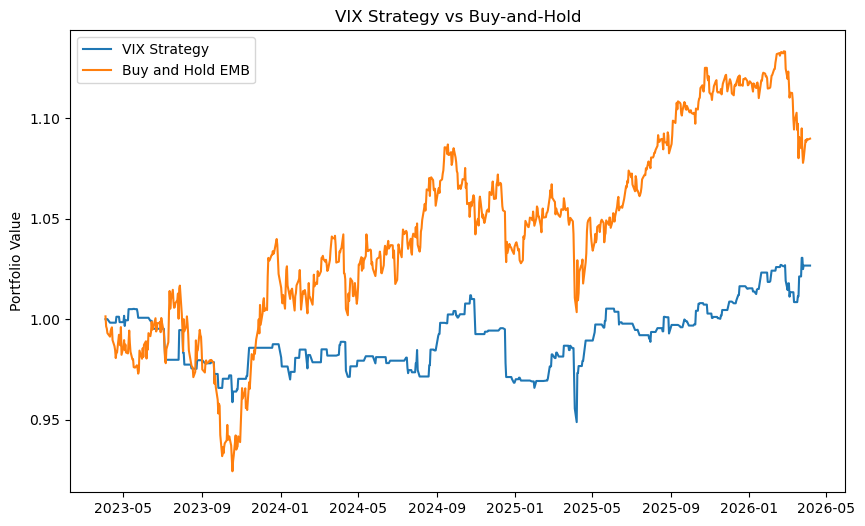

In [213]:
"""Buy-and-hold means purchasing EMB at the beginning of the test period and remaining continuously invested without responding to the model's signals.
Ends at 11%  returns for buy and hold, whereas our strategy ends at 2.5% returns
Blue line is our strategy, orange line is buy and hold EMB strategy (do nothing)
Blue line below orange line for the most part, so our strategy is worse off than doing nothing 
and it often underperforms.
The strategy is too conservative, so we don't get much upside. This is illustrated in the previous
graph above where we had many instances of plateaus (signals being 0 which meant don't invest)!
Also, when buy and hold drops a lot, so does our strategy - you don't have an advantage over doing nothing
in times of downturns.
Thus, this suggests that vix_delta lacks predictive power, and even though it had the highest
R-squared value of 0.006, this is not nearly enough to help it predict tomorrow's emb_returns
to deliver an effective trading strategy. There is too much noise when trying to use today's vix_delta
to predict tomorrow's emb_returns"""


test["cum_buy_hold"] = np.exp(
    test["target"].cumsum()
)

import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.plot(test.index, test["cum_return_vix"], label="VIX Strategy")
plt.plot(test.index, test["cum_buy_hold"], label="Buy and Hold EMB")
plt.title("VIX Strategy vs Buy-and-Hold")
plt.ylabel("Portfolio Value")
plt.legend()
plt.show()

In [214]:
import statsmodels.api as sm

# Define X and y
X_train = train[["oil_return", "delta_vix", "delta_spread"]]
X_train = sm.add_constant(X_train)

y_train = train["target"]

# Run regression (use robust SEs)
# HC3 produces heteroskedasticity-robust standard errors, which changes
# standard errors, confidence intervals, and p-values but not OLS coefficients.
model_full = sm.OLS(y_train, X_train).fit(cov_type='HC3')

print(model_full.summary())

"""With multivariate linear regression, the predictors (valued at time t) are individually not statistically significant anymore,
when they are combined together to simultaneously explain emb_returns at time t+1 in this multivariate model"""
#All the p-values are much greater than 5% level of significance
#This is due to multicollinearity! 
#The predictor variables are highly correlated with each other, so there is shared explanatory power
#This relates to how we found a correlation of 0.45 between vix_delta and spread_delta
#So the multivariate regression aims to see what each predictor variable explains that the others don't already explain
#But, if there is multicollinearity, that means multiple predictors are explaining the same outcome 
#Thus, the other predictors aren't really adding much value/explaining much more
#This strong multicollinearity is demonstrated by the condition number of 84 - which is very high
#For reference, below 10 is very good (little to no), 10-30 is moderate, and above 30 means severe multicollinearity
#This means we should not include all predictors, and maybe a simpler model is more effective
"""Although R-squared did increase from 0.006 (with vix_delta only) to 0.008 with all 3 predictors,
it was not worthwhile adding these additional predictors because the predictors individually lost
statistical significance, and the relationship became much more noisy due to multicollinearity"""
"""****Conceptual Note: Multicollinearity is about correlation between the predictor variables, 
which are all measured at time t! So, discussing the correlation results we found in the correlation matrix
are appropriate when analyzing the multicollinearity issue (i.e. correlation of 0.45 between delta_vix and delta_spreads,
both of which are measured at time t)!"""

"""
The decline in individual significance may partly reflect overlapping information among the predictors. 
VIX and credit-spread changes are moderately correlated, which can increase coefficient uncertainty. 
Ridge regression is therefore explored as a way to regularize and stabilize the multifactor model.
"""



                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                    0.8244
Date:                Wed, 09 Sep 2026   Prob (F-statistic):              0.480
Time:                        22:20:09   Log-Likelihood:                 6256.5
No. Observations:                1757   AIC:                        -1.250e+04
Df Residuals:                    1753   BIC:                        -1.248e+04
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.0001      0.000     -0.835   

'\nThe decline in individual significance may partly reflect overlapping information among the predictors. \nVIX and credit-spread changes are moderately correlated, which can increase coefficient uncertainty. \nRidge regression is therefore explored as a way to regularize and stabilize the multifactor model.\n'

In [215]:
#Step 2: Prepare test data (IMPORTANT: add constant)
X_test = sm.add_constant(test[["oil_return", "delta_vix", "delta_spread"]])
y_test = test["target"]

#Step 3: Make predictions on test
test_pred = model_full.predict(X_test)

#Step 4: Compute test R²
from sklearn.metrics import r2_score

test_r2 = r2_score(y_test, test_pred)

print("3 Factor (no ridge) Test R²:", test_r2)

3 Factor (no ridge) Test R²: -0.01622494276049702


In [216]:
# 2. Predict on the test set
X_test_full = sm.add_constant(test[["oil_return", "delta_vix", "delta_spread"]])
test.loc[:, "pred_full"] = model_full.predict(X_test_full)

# 3. Convert predictions into trading signals
# Long-only: invest if predicted next-day EMB return is positive, otherwise stay in cash
test.loc[:, "signal_full"] = (test["pred_full"] > 0).astype(int)

# 4. Compute realized strategy returns
test.loc[:, "strategy_return_full"] = test["signal_full"] * test["target"]

# 5. Sharpe ratio
daily_sharpe_full = (
    test["strategy_return_full"].mean()
    / test["strategy_return_full"].std()
)

annualized_sharpe_full = daily_sharpe_full * np.sqrt(252)

print("Daily Sharpe - 3 Factor OLS:", daily_sharpe_full)
print("Annualized Sharpe - 3 Factor OLS:", annualized_sharpe_full)

Daily Sharpe - 3 Factor OLS: 0.05265524959980414
Annualized Sharpe - 3 Factor OLS: 0.8358761739786904


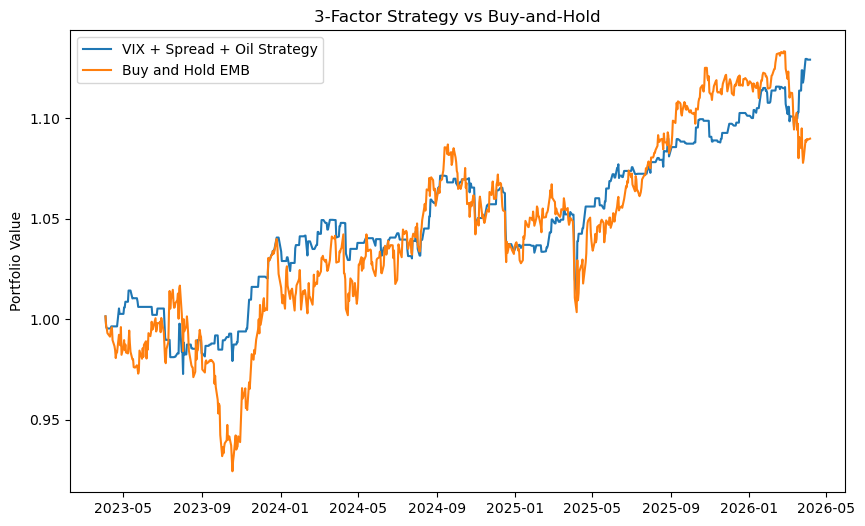

In [217]:
# 6. Cumulative returns
test.loc[:, "cum_return_full"] = np.exp(
    test["strategy_return_full"].cumsum()
)

# 7. Buy-and-hold benchmark
test.loc[:, "cum_buy_hold"] = np.exp(
    test["target"].cumsum()
)

# 8. Plot strategy vs buy-and-hold
plt.figure(figsize=(10, 6))
plt.plot(test.index, test["cum_return_full"], label="VIX + Spread + Oil Strategy")
plt.plot(test.index, test["cum_buy_hold"], label="Buy and Hold EMB")
plt.title("3-Factor Strategy vs Buy-and-Hold")
plt.ylabel("Portfolio Value")
plt.legend()
plt.show()

Maximum training R²: 0.007520275133735432
99% threshold: 0.007445072382398078
Chosen alpha (more robust): 100.0

Eligible alphas:
         alpha  train_r2   test_r2
0     0.001000  0.007520 -0.016225
1     0.001343  0.007520 -0.016225
2     0.001805  0.007520 -0.016225
3     0.002424  0.007520 -0.016225
4     0.003257  0.007520 -0.016225
5     0.004375  0.007520 -0.016225
6     0.005878  0.007520 -0.016225
7     0.007897  0.007520 -0.016225
8     0.010608  0.007520 -0.016225
9     0.014251  0.007520 -0.016225
10    0.019145  0.007520 -0.016225
11    0.025719  0.007520 -0.016225
12    0.034551  0.007520 -0.016224
13    0.046416  0.007520 -0.016224
14    0.062355  0.007520 -0.016224
15    0.083768  0.007520 -0.016224
16    0.112534  0.007520 -0.016223
17    0.151178  0.007520 -0.016223
18    0.203092  0.007520 -0.016222
19    0.272833  0.007520 -0.016221
20    0.366524  0.007520 -0.016220
21    0.492388  0.007520 -0.016218
22    0.661474  0.007520 -0.016215
23    0.888624  0.007520 -0.01

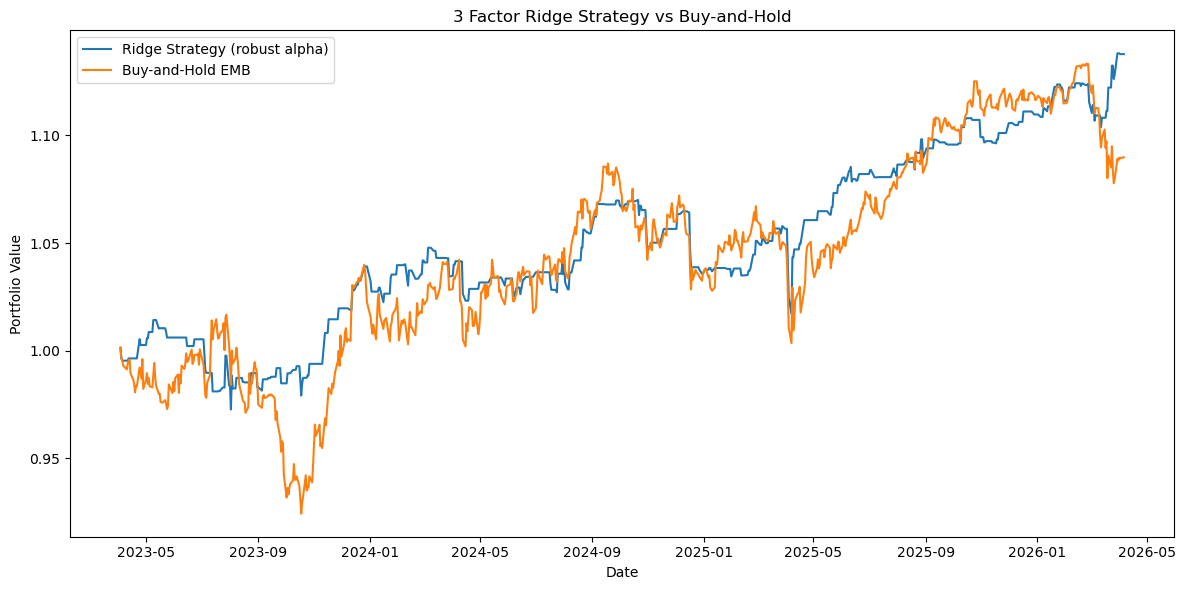

In [218]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# Notes on Choosing Alpha - its about fit-regularization trade-off
# Find the highest training R-Squared, keep every alpha whose training R-Squared is at least 99% of that maxinmum, and among those models choose the highest alpha
# We found the following:
"""
Maximum training R² = 0.007520
99% threshold       = 0.007445
Chosen alpha        = 100
"""
# Idea: I'm willing to sacrifice up to about 1% of the model's maximum training fit in exchange for stronger Ridge regularization.
# USing larger alpha value as proxy for stability --> more coefficient shrinkage --> reduces impact of correlated predictors
# How much model fit are we willing to give up for a simpler, more stable Ridge model --> that's fit-regularization trade-off
"""
A very small alpha behaves more like OLS: it tries harder to fit the training data. 
A larger alpha shrinks the coefficients more, which makes the model less sensitive to noise and correlated predictors, 
but if alpha gets too large, you can shrink the coefficients too much and hurt the model's fit.
"""
# -----------------------------
# 1. Prepare data
# -----------------------------
X_train = train[["oil_return", "delta_vix", "delta_spread"]]
y_train = train["target"]

X_test = test[["oil_return", "delta_vix", "delta_spread"]]
y_test = test["target"]

# -----------------------------
# 2. Search over alpha values
# -----------------------------
alphas = np.logspace(-3, 2, 40)   # from 0.001 to 100

results = []

for a in alphas:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=a))
    ])
    
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)
    
    results.append({
        "alpha": a,
        "train_r2": train_r2,
        "test_r2": test_r2
    })

results_df = pd.DataFrame(results)

# -----------------------------
# 3. More robust alpha selection
#    Keep alphas with train R² within 99% of max,
#    then choose the largest alpha for stability
# -----------------------------
max_train_r2 = results_df["train_r2"].max()
threshold = max_train_r2 * 0.99

eligible = results_df[results_df["train_r2"] >= threshold].copy()

best_alpha = eligible["alpha"].max()

print("Maximum training R²:", max_train_r2)
print("99% threshold:", threshold)
print("Chosen alpha (more robust):", best_alpha)

# Optional: inspect candidate alphas
print("\nEligible alphas:")
print(eligible[["alpha", "train_r2", "test_r2"]])

# -----------------------------
# 4. Fit final ridge model
# -----------------------------
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=best_alpha))
])

final_model.fit(X_train, y_train)

# -----------------------------
# Coefficients in both scaled and original units
# -----------------------------
scaler_step = final_model.named_steps["scaler"]
ridge_step = final_model.named_steps["ridge"]

feature_names = ["oil_return", "delta_vix", "delta_spread"]

# Coefficients from ridge on standardized variables
beta_scaled = ridge_step.coef_
intercept_scaled = ridge_step.intercept_

# Means and standard deviations from scaler
means = scaler_step.mean_
scales = scaler_step.scale_

# Convert back to original-variable units
beta_original = beta_scaled / scales
intercept_original = intercept_scaled - np.sum(beta_scaled * means / scales)

# DataFrame for display
coef_compare_df = pd.DataFrame({
    "Feature": feature_names,
    "Scaled_Coefficient": beta_scaled,
    "Original_Coefficient": beta_original
})

print("\nIntercept (scaled model):", intercept_scaled)
print("Intercept (original units):", intercept_original)

print("\nRidge coefficients:")
print(coef_compare_df)

print("\nFinal Ridge Equation (original units):")
print(
    f"target_hat = {intercept_original:.8f}"
    f" + ({beta_original[0]:.8f}) * oil_return"
    f" + ({beta_original[1]:.8f}) * delta_vix"
    f" + ({beta_original[2]:.8f}) * delta_spread"
)

# Predictions
train_pred_final = final_model.predict(X_train)
test_pred_final = final_model.predict(X_test)

# R-squared
train_r2_final = r2_score(y_train, train_pred_final)
test_r2_final = r2_score(y_test, test_pred_final)

print("\nFinal model metrics")
print("Train R²:", train_r2_final)
print("Test R²:", test_r2_final)

# -----------------------------
# 5. Trading strategy on test set
#    Long-only: invest if predicted return > 0
# -----------------------------
test = test.copy()

test.loc[:, "pred_ridge_robust"] = test_pred_final
test.loc[:, "signal_ridge_robust"] = (test["pred_ridge_robust"] > 0).astype(int)
test.loc[:, "strategy_return_ridge_robust"] = (
    test["signal_ridge_robust"] * test["target"]
)

# Sharpe ratio
daily_sharpe_ridge = (
    test["strategy_return_ridge_robust"].mean()
    / test["strategy_return_ridge_robust"].std()
)

annualized_sharpe_ridge = daily_sharpe_ridge * np.sqrt(252)

print("Daily Sharpe - Ridge:", daily_sharpe_ridge)
print("Annualized Sharpe - Ridge:", annualized_sharpe_ridge)

# -----------------------------
# 6. Coefficients
#    Note: these are on standardized features
# -----------------------------
ridge_step = final_model.named_steps["ridge"]

coef_df = pd.DataFrame({
    "Feature": ["oil_return", "delta_vix", "delta_spread"],
    "Coefficient": ridge_step.coef_
})

print("\nIntercept:", ridge_step.intercept_)
print("\nRidge coefficients (standardized features):")
print(coef_df)

# -----------------------------
# 7. Cumulative returns + benchmark
# -----------------------------
test.loc[:, "cum_return_ridge_robust"] = np.exp(
    test["strategy_return_ridge_robust"].cumsum()
)

test.loc[:, "cum_buy_hold"] = np.exp(
    test["target"].cumsum()
)

# If date is still a column, use it as index for nicer plotting
if "date" in test.columns:
    test = test.set_index("date")

# -----------------------------
# 8. Plot strategy vs buy-and-hold
# -----------------------------
plt.figure(figsize=(12, 6))
plt.plot(test.index, test["cum_return_ridge_robust"], label="Ridge Strategy (robust alpha)")
plt.plot(test.index, test["cum_buy_hold"], label="Buy-and-Hold EMB")

plt.title("3 Factor Ridge Strategy vs Buy-and-Hold")
plt.ylabel("Portfolio Value")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

In [219]:
# Rebuild cumulative return columns safely

test["cum_return_vix"] = np.exp(
    test["strategy_return_vix"].cumsum()
)
test["cum_return_full"] = np.exp(
    test["strategy_return_full"].cumsum()
)
test["cum_return_ridge_robust"] = np.exp(
    test["strategy_return_ridge_robust"].cumsum()
)
test["cum_buy_hold"] = np.exp(
    test["target"].cumsum()
)

print(test[[
    "cum_return_vix",
    "cum_return_full",
    "cum_return_ridge_robust",
    "cum_buy_hold"
]].tail())

            cum_return_vix  cum_return_full  cum_return_ridge_robust  \
date                                                                   
2026-03-30        1.026676         1.129538                 1.138103   
2026-03-31        1.026676         1.129538                 1.138103   
2026-04-01        1.026676         1.129538                 1.138103   
2026-04-02        1.026676         1.129178                 1.137740   
2026-04-06        1.026676         1.129178                 1.137740   

            cum_buy_hold  
date                      
2026-03-30      1.089170  
2026-03-31      1.088358  
2026-04-01      1.089634  
2026-04-02      1.089286  
2026-04-06      1.089865  


In [220]:
print(test[
    [
        "cum_return_vix",
        "cum_return_full",
        "cum_return_ridge_robust",
        "cum_buy_hold"
    ]
].tail())

"""
VIX strategy:       1.026676  → +2.67%
3-factor OLS:       1.129178  → +12.92%
Ridge:              1.137740  → +13.77%
Buy-and-hold EMB:   1.089865  → +8.99%
"""

            cum_return_vix  cum_return_full  cum_return_ridge_robust  \
date                                                                   
2026-03-30        1.026676         1.129538                 1.138103   
2026-03-31        1.026676         1.129538                 1.138103   
2026-04-01        1.026676         1.129538                 1.138103   
2026-04-02        1.026676         1.129178                 1.137740   
2026-04-06        1.026676         1.129178                 1.137740   

            cum_buy_hold  
date                      
2026-03-30      1.089170  
2026-03-31      1.088358  
2026-04-01      1.089634  
2026-04-02      1.089286  
2026-04-06      1.089865  


'\nVIX strategy:       1.026676  → +2.67%\n3-factor OLS:       1.129178  → +12.92%\nRidge:              1.137740  → +13.77%\nBuy-and-hold EMB:   1.089865  → +8.99%\n'